In [33]:
# Bibliotecas utilizadas no notebook

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split # separação entre treino e teste
from sklearn.preprocessing import StandardScaler # normalização das features

from sklearn.svm import SVC # modelo SVM para classificação
from sklearn.ensemble import RandomForestClassifier # modelo Random Forest

from sklearn.metrics import (
    accuracy_score, # acurácia do modelo
    precision_score, # precisão
    recall_score, # recall (sensibilidade)
    f1_score, # F1-score
    confusion_matrix, # matriz de confusão
    classification_report # relatório completo de métricas
)

import seaborn as sns # visualização estatística
import matplotlib.pyplot as plt # gráficos e plots

import matplotlib.pyplot as plt
import cv2
import os
from pathlib import Path

In [34]:
# Carregamento dos dados
# Este bloco realiza a leitura dos arquivos gerados no notebook anterior contendo:
# - X: features extraídas das imagens
# - y: rótulos (classes)

# Carrega a matriz de features
X = pd.read_csv("../outputs/X.csv")

# Carrega os rótulos das classes
y = pd.read_csv("../outputs/y.csv")

# Verifica as dimensões dos conjuntos carregados
print(X.shape)
print(y.shape)

(10901, 19)
(10901, 1)


<class 'pandas.core.frame.DataFrame'>


,classe
0,freshapples
1,freshapples
2,freshapples
3,freshapples
4,freshapples


classe
freshapples      1693
freshbanana      1581
freshoranges     1466
rottenapples     2342
rottenbanana     2224
rottenoranges    1595
Name: count, dtype: int64

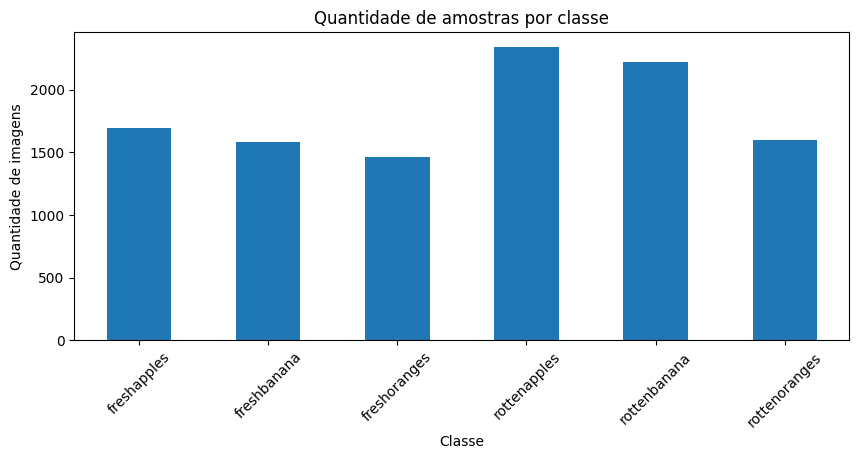

In [35]:
# Verificação do balanceamento das classes
# Esta etapa confirma quantas amostras existem por classe antes do treino.

print(type(y))
display(y.head())

if isinstance(y, pd.DataFrame):
    y_contagem = y.iloc[:, 0]
else:
    y_contagem = y

contagem_classes = y_contagem.value_counts().sort_index()
display(contagem_classes)

plt.figure(figsize=(10, 4))
contagem_classes.plot(kind="bar")
plt.title("Quantidade de amostras por classe")
plt.xlabel("Classe")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=45)
plt.show()

In [36]:
# Visualização inicial dos dados
# Este bloco permite uma inspeção rápida das primeiras linhas do conjunto de features (X), verificando sua estrutura

X.head()

,area,perimeter,solidity,extent,circularity,hu1,hu2,hu3,hu4,hu5,hu6,hu7,mean_r,mean_g,mean_b,contrast,homogeneity,energy,correlation
0,92063.0,1633.675324,0.896785,0.687514,0.433474,-7.288765,-18.405711,-22.794553,-23.006669,-23.025851,-23.025849,-23.025851,68.480111,22.711208,19.768366,108.399132,0.747537,0.574706,0.973669
1,8537.0,477.445743,0.883747,0.514029,0.470616,-6.837603,-14.174590,-22.747468,-22.990158,-23.025851,-23.025843,-23.025851,4.052850,4.508604,2.222170,15.045936,0.977066,0.952294,0.979499
2,112053.0,2061.162697,0.918633,0.663546,0.331443,-7.345807,-20.754250,-22.990625,-23.023668,-23.025851,-23.025851,-23.025851,94.822364,32.329702,37.082625,138.915756,0.705564,0.428023,0.971791
3,97967.0,1577.882430,0.965706,0.760283,0.494471,-7.370229,-20.176761,-23.009281,-23.025812,-23.025851,-23.025851,-23.025851,110.861366,45.103875,44.531693,144.228489,0.641791,0.427509,0.980827
4,76243.0,1769.120021,0.869342,0.623879,0.306122,-7.309996,-18.326307,-22.853449,-22.993886,-23.025851,-23.025848,-23.025851,85.067871,43.621429,35.882100,166.207733,0.704096,0.536441,0.980357


In [37]:
# Distribuição das classes
# Este bloco mostra a quantidade de amostras por classe, permitindo verificar se o dataset está balanceado

print(y["classe"].value_counts())

classe
rottenapples     2342
rottenbanana     2224
freshapples      1693
rottenoranges    1595
freshbanana      1581
freshoranges     1466
Name: count, dtype: int64


In [38]:
# Divisão dos dados
# Este bloco separa o dataset em três conjuntos:
# - Treino (treinamento do modelo)
# - Validação (ajuste de parâmetros e avaliação intermediária)
# - Teste (avaliação final do modelo)

# Primeira divisão: treino (70%) e restante (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y["classe"],
    test_size=0.30,
    stratify=y["classe"],
    random_state=42
)

# Segunda divisão: validação (50% do restante) e teste (50% do restante)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

# Verificação das dimensões dos conjuntos
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (7630, 19)
Validação: (1635, 19)
Teste: (1636, 19)


In [39]:
# Normalização das features
# Este bloco aplica padronização (StandardScaler) nas features, garantindo que todas estejam na mesma escala
# Isso é importante para melhorar o desempenho dos modelos

# Inicializa o normalizador
scaler = StandardScaler()

# Ajusta o scaler apenas com os dados de treino e transforma
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação nos dados de validação
X_val_scaled = scaler.transform(X_val)

# Aplica a mesma transformação nos dados de teste
X_test_scaled = scaler.transform(X_test)

# Confirmação do processo
print("Padronização concluída.")

Padronização concluída.


In [40]:
# Treinamento - Random Forest
# Este bloco treina um modelo Random Forest utilizando os dados normalizados e realiza previsões no conjunto de teste

# Inicialização do modelo Random Forest
rf = RandomForestClassifier(
    n_estimators=200, # número de árvores na floresta
    random_state=42 # reprodutibilidade dos resultados
)

# Treinamento do modelo com os dados de treino
rf.fit(X_train_scaled, y_train)

# Predição no conjunto de teste
pred_rf = rf.predict(X_test_scaled)

In [41]:
# Avaliação do modelo Random Forest
# Este bloco calcula métricas de desempenho do modelo Random Forest com base nas previsões realizadas no conjunto de teste

# Acurácia do modelo
acc_rf = accuracy_score(y_test, pred_rf)

# Precisão ponderada (considera desbalanceamento entre classes)
prec_rf = precision_score(y_test, pred_rf, average="weighted")

# Recall ponderado
rec_rf = recall_score(y_test, pred_rf, average="weighted")

# F1-score ponderado
f1_rf = f1_score(y_test, pred_rf, average="weighted")

# Exibição dos resultados
print("Accuracy:", acc_rf)
print("Precision:", prec_rf)
print("Recall:", rec_rf)
print("F1:", f1_rf)

Accuracy: 0.7921760391198044
Precision: 0.8049106466915338
Recall: 0.7921760391198044
F1: 0.7924285908898565


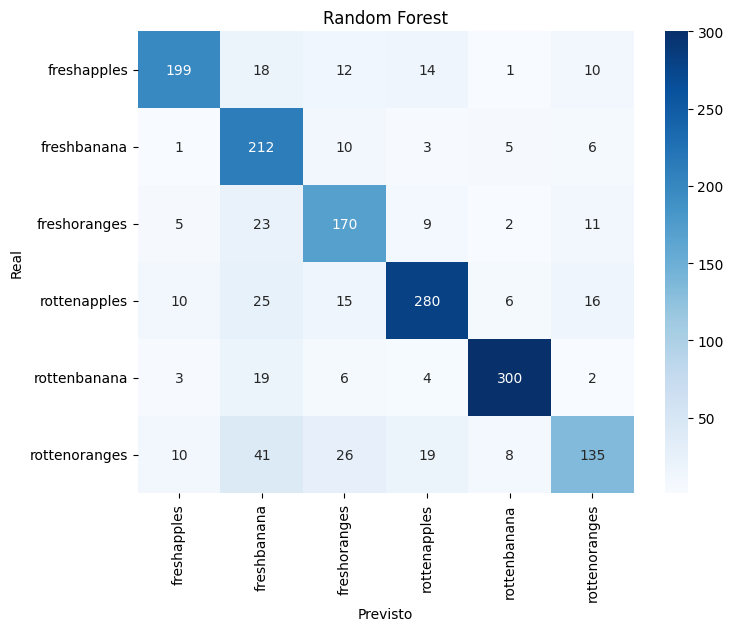

In [42]:
# Matriz de confusão - Random Forest
# Este bloco gera a matriz de confusão do modelo Random Forest, permitindo visualizar acertos e erros de classificação por classe

# Cálculo da matriz de confusão
cm_rf = confusion_matrix(y_test, pred_rf)

# Configuração do tamanho do gráfico
plt.figure(figsize=(8,6))

# Plot da matriz de confusão
sns.heatmap(
    cm_rf,
    annot=True, # exibe os valores nas células
    fmt="d", # formato inteiro
    cmap="Blues",
    xticklabels=sorted(y["classe"].unique()),
    yticklabels=sorted(y["classe"].unique())
)

# Título do gráfico
plt.title("Random Forest")

# Rótulos dos eixos
plt.xlabel("Previsto")
plt.ylabel("Real")


# Salvamento da imagem da matriz de confusão
plt.savefig("../outputs/confusion_matrix_rf.png", bbox_inches="tight")

# Exibição do gráfico
plt.show()

In [43]:
# Treinamento - SVM
# Este bloco treina um modelo Support Vector Machine (SVM) com kernel RBF e realiza previsões no conjunto de teste

# Inicialização do modelo SVM
svm = SVC(
    kernel="rbf", # kernel radial basis function
    random_state=42 # reprodutibilidade dos resultados
)

# Treinamento do modelo com os dados de treino
svm.fit(X_train_scaled, y_train)

# Predição no conjunto de teste
pred_svm = svm.predict(X_test_scaled)

In [44]:
# Métricas SVM
# Este bloco calcula as principais métricas de avaliação do modelo SVM utilizando as previsões realizadas no conjunto de teste

# Cálculo da acurácia
# Mede a proporção de previsões corretas em relação ao total de amostras avaliadas
acc_svm = accuracy_score(y_test, pred_svm)

# Cálculo da precisão
# Mede a proporção de classificações positivas corretas
# O parâmetro "weighted" calcula a média ponderada pelo número de amostras de cada classe
prec_svm = precision_score(y_test, pred_svm, average="weighted")

# Cálculo do recall (revocação)
# Mede a capacidade do modelo de identificar corretamente os exemplos pertencentes a cada classe
rec_svm = recall_score(y_test, pred_svm, average="weighted")

# Cálculo do F1-Score
# Combina precisão e recall em uma única métrica, representando o equilíbrio entre ambas
f1_svm = f1_score(y_test, pred_svm, average="weighted")

# Exibição das métricas calculadas
print("Accuracy:", acc_svm)
print("Precision:", prec_svm)
print("Recall:", rec_svm)
print("F1:", f1_svm)

Accuracy: 0.6503667481662592
Precision: 0.6619466985810082
Recall: 0.6503667481662592
F1: 0.6376594233249272


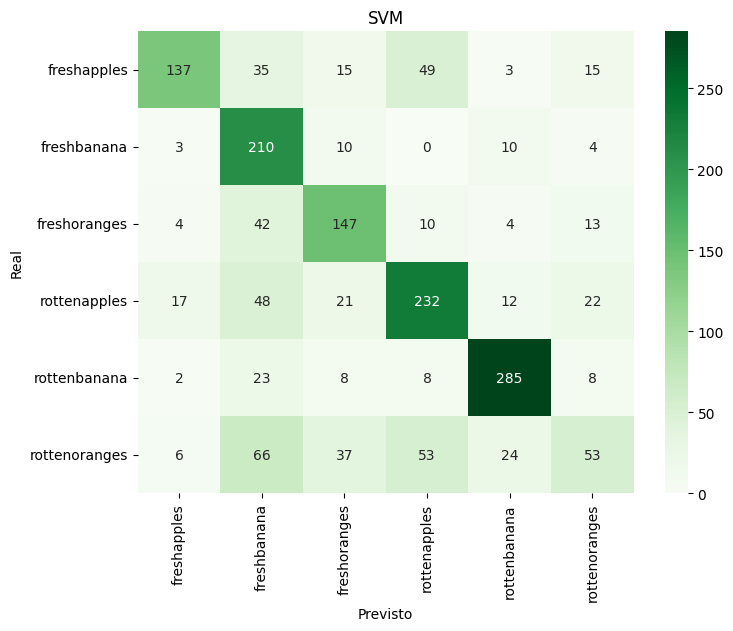

In [45]:
# Matriz de confusão - SVM
# Este bloco gera a matriz de confusão do modelo SVM, permitindo visualizar os acertos e erros de classificação para cada classe presente no conjunto de teste

# Cálculo da matriz de confusão
# Compara os valores reais com os valores previstos pelo modelo
cm_svm = confusion_matrix(y_test, pred_svm)

# Criação da figura para exibição da matriz
plt.figure(figsize=(8,6))

# Geração do mapa de calor (heatmap) da matriz de confusão
sns.heatmap(
    cm_svm,
    annot=True, # annot=True exibe os valores em cada célula
    fmt="d", # fmt="d" formata os valores como números inteiros
    cmap="Greens", # cmap="Greens" define a paleta de cores utilizada
    xticklabels=sorted(y["classe"].unique()),
    yticklabels=sorted(y["classe"].unique())
)

# Define o título do gráfico
plt.title("SVM")

# Rótulo do eixo X (classes previstas pelo modelo)
plt.xlabel("Previsto")

# Rótulo do eixo Y (classes reais)
plt.ylabel("Real")

# Salva a figura gerada no diretório de saída
plt.savefig("../outputs/confusion_matrix_svm.png", bbox_inches="tight")

# Salva a figura gerada no diretório de saída
plt.show()

In [46]:
# Validação cruzada
# Este bloco exibe o relatório de classificação para os modelos Random Forest e SVM, permitindo uma análise detalhada do desempenho de cada classe

# Exibição do relatório de classificação do Random Forest
# O relatório apresenta métricas como precisão (precision), recall, F1-score e suporte (support) para cada classe
print("RANDOM FOREST")
print(classification_report(y_test, pred_rf))

print()

# Exibição do relatório de classificação do SVM
# Permite comparar o desempenho do modelo SVM com o Random Forest utilizando as mesmas métricas
print("SVM")
print(classification_report(y_test, pred_svm))

RANDOM FOREST
               precision    recall  f1-score   support

  freshapples       0.87      0.78      0.83       254
  freshbanana       0.63      0.89      0.74       237
 freshoranges       0.71      0.77      0.74       220
 rottenapples       0.85      0.80      0.82       352
 rottenbanana       0.93      0.90      0.91       334
rottenoranges       0.75      0.56      0.64       239

     accuracy                           0.79      1636
    macro avg       0.79      0.78      0.78      1636
 weighted avg       0.80      0.79      0.79      1636


SVM
               precision    recall  f1-score   support

  freshapples       0.81      0.54      0.65       254
  freshbanana       0.50      0.89      0.64       237
 freshoranges       0.62      0.67      0.64       220
 rottenapples       0.66      0.66      0.66       352
 rottenbanana       0.84      0.85      0.85       334
rottenoranges       0.46      0.22      0.30       239

     accuracy                           0

In [47]:
# Tabela comparativa
# Este bloco cria uma tabela consolidada contendo as principais métricas de desempenho dos modelos
# Random Forest e SVM, facilitando a comparação dos resultados

# Criação do DataFrame com as métricas de avaliação
resultados = pd.DataFrame({
    # Nome dos modelos avaliados
    "Modelo": [
        "Random Forest",
        "SVM"
    ],

    # Acurácia de cada modelo
    # Representa a proporção total de classificações corretas
    "Accuracy": [
        acc_rf,
        acc_svm
    ],

    # Precisão de cada modelo
    # Mede a proporção de previsões positivas corretas
    "Precision": [
        prec_rf,
        prec_svm
    ],
    
    # Recall de cada modelo
    # Mede a capacidade de identificar corretamente os exemplos pertencentes a cada classe
    "Recall": [
        rec_rf,
        rec_svm
    ],

    # F1-Score de cada modelo
    # Métrica que combina precisão e recall em uma única medida
    "F1": [
        f1_rf,
        f1_svm
    ]
})

# Exibição da tabela comparativa com os resultados dos modelos
resultados

,Modelo,Accuracy,Precision,Recall,F1
0,Random Forest,0.792176,0.804911,0.792176,0.792429
1,SVM,0.650367,0.661947,0.650367,0.637659


In [48]:
# Salvar resultados
# Este bloco salva a tabela comparativa de métricas em um arquivo CSV, permitindo o armazenamento e a utilização
# posterior dos resultados obtidos pelos modelos

# Exportação da tabela de resultados para um arquivo CSV
# index=False evita que o índice do DataFrame seja salvo como uma coluna adicional no arquivo
resultados.to_csv("../outputs/tabela_metricas.csv", index=False )

# Mensagem de confirmação indicando que o arquivo foi salvo com sucesso no diretório especificado
print("Tabela salva.")

Tabela salva.


,arquivo,classe,caminho_original
0,fruit_0.png,freshapples,../dataset/train\freshapples\rotated_by_15_Scr...
1,fruit_1.png,freshapples,../dataset/train\freshapples\rotated_by_15_Scr...
2,fruit_2.png,freshapples,../dataset/train\freshapples\rotated_by_15_Scr...
3,fruit_3.png,freshapples,../dataset/train\freshapples\rotated_by_15_Scr...
4,fruit_4.png,freshapples,../dataset/train\freshapples\rotated_by_15_Scr...


Index(['arquivo', 'classe', 'caminho_original'], dtype='object')


,real,previsto
2209,freshbanana,rottenoranges
4501,freshoranges,freshbanana
9933,rottenoranges,freshbanana
3710,freshoranges,rottenoranges
2559,freshbanana,freshoranges
1400,freshapples,freshbanana
10074,rottenoranges,freshapples
5081,rottenapples,freshbanana
521,freshapples,freshbanana
10400,rottenoranges,freshoranges


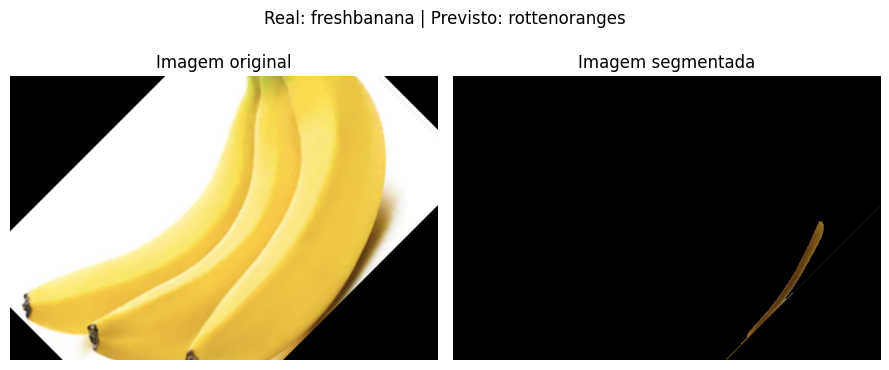

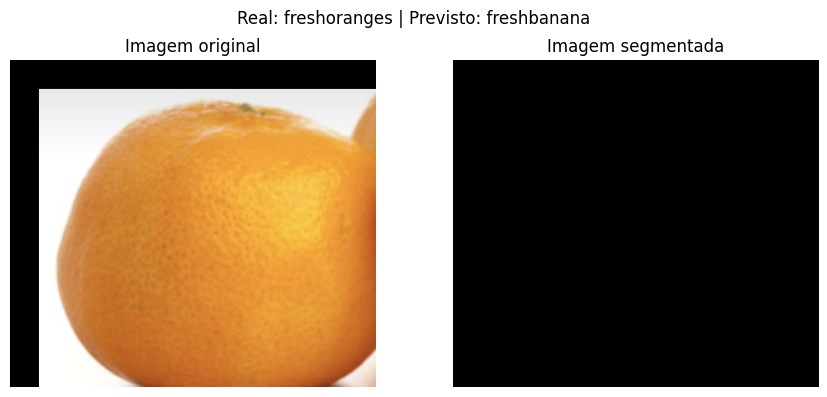

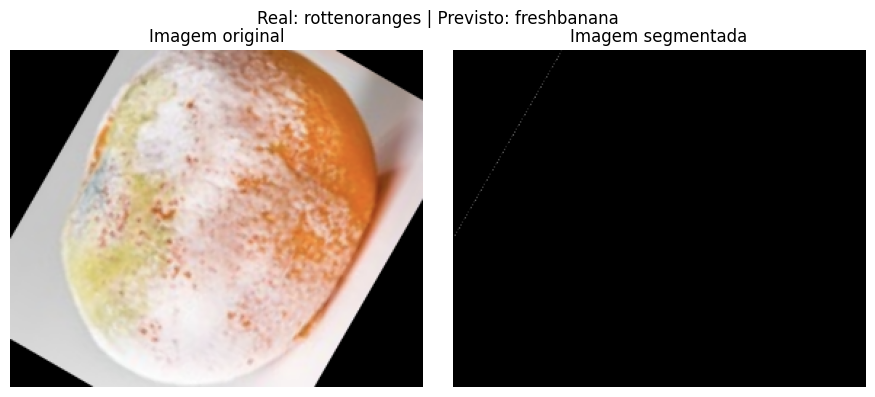

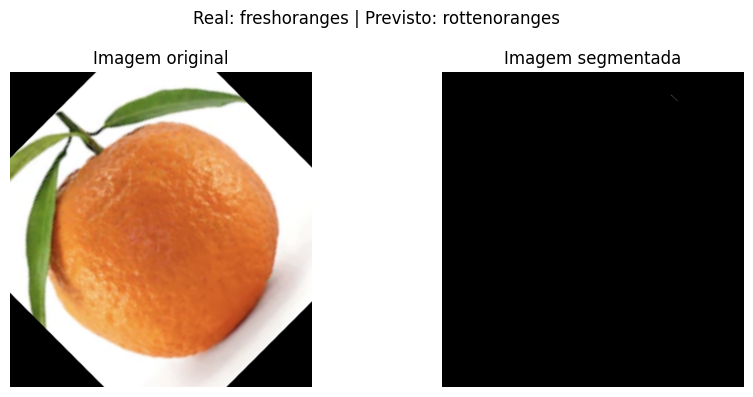

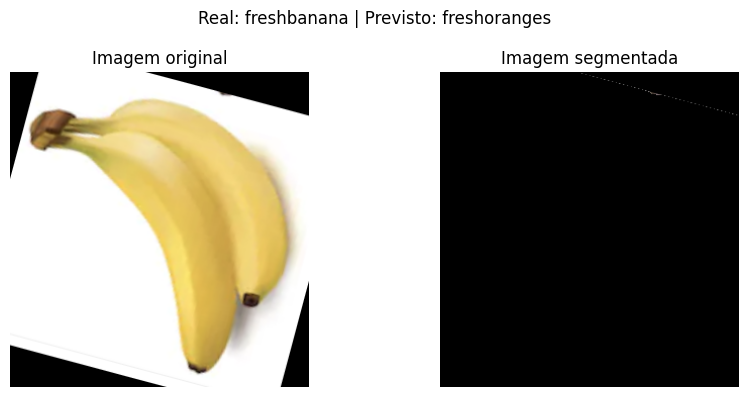

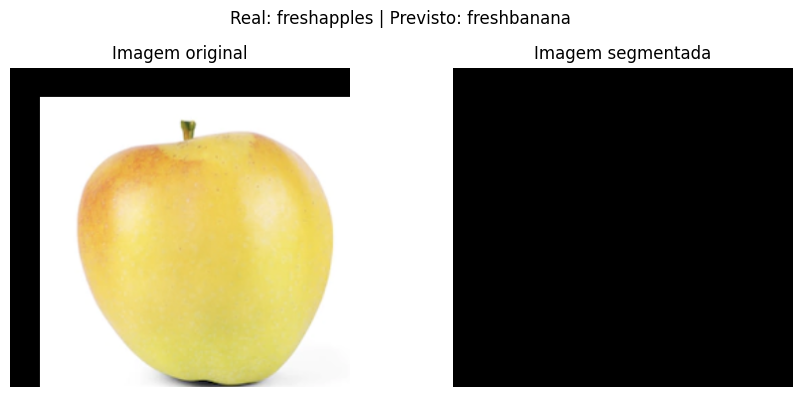

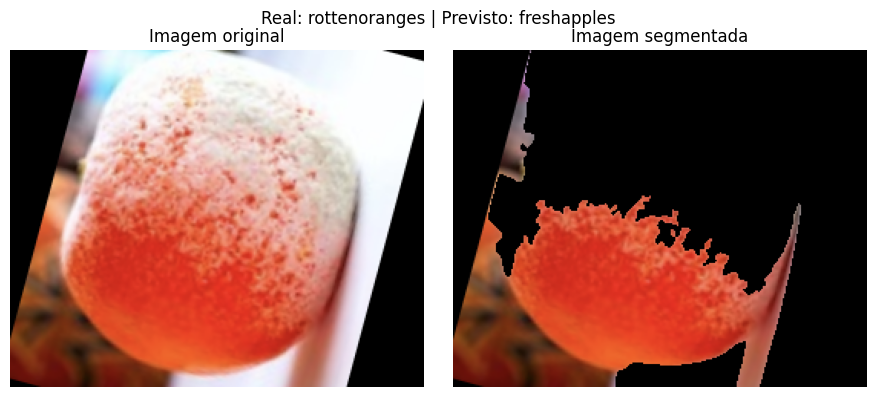

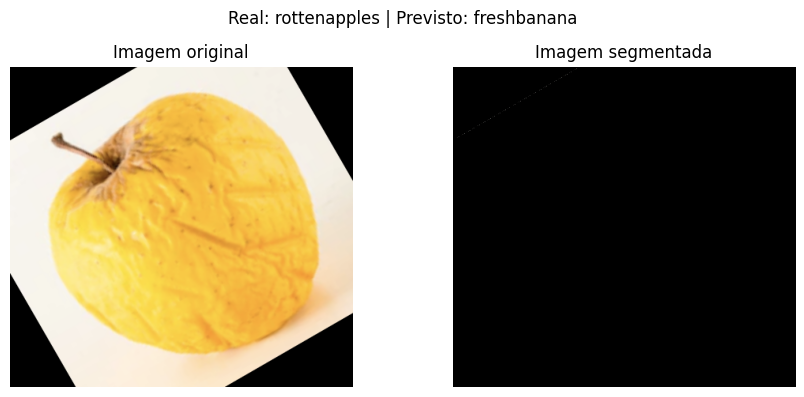

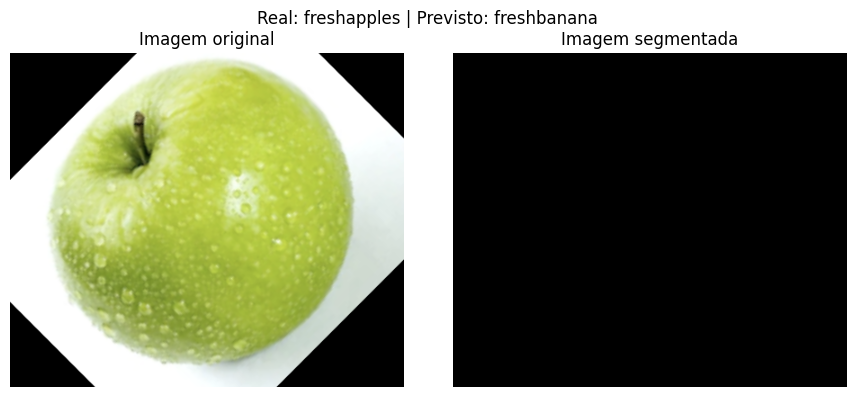

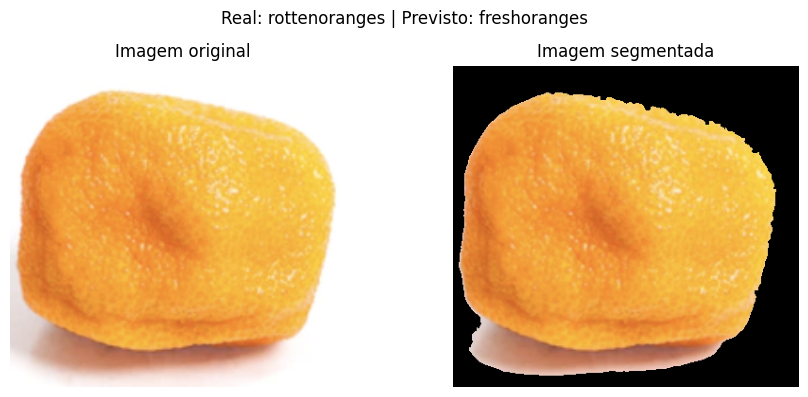

In [49]:
# Análise visual dos erros de classificação
# Mostra a imagem original e a imagem segmentada para investigar possíveis causas do erro.
# Requer que o classes.csv tenha as colunas: arquivo, classe, caminho_original.

segmented_path = Path("../outputs/segmented_images")

classes_df = pd.read_csv("../outputs/classes.csv")

# Conferência rápida das colunas esperadas
display(classes_df.head())
print(classes_df.columns)

erros_rf = pd.DataFrame({
    "real": y_test.values,
    "previsto": pred_rf
}, index=y_test.index)

erros_rf = erros_rf[erros_rf["real"] != erros_rf["previsto"]]

display(erros_rf.head(10))

for idx, row_erro in erros_rf.head(10).iterrows():
    classe_real = row_erro["real"]
    classe_prevista = row_erro["previsto"]

    nome_arquivo = classes_df.loc[idx, "arquivo"]

    # Agora o caminho original vem diretamente do classes.csv
    caminho_original = Path(classes_df.loc[idx, "caminho_original"])
    caminho_segmentado = segmented_path / nome_arquivo

    img_original = cv2.imread(str(caminho_original))
    img_segmentada = cv2.imread(str(caminho_segmentado))

    plt.figure(figsize=(9, 4))

    plt.subplot(1, 2, 1)
    if img_original is not None:
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        plt.imshow(img_original)
        plt.title("Imagem original")
    else:
        plt.text(
            0.5, 0.5,
            f"Original não encontrada:\n{caminho_original}",
            ha="center",
            va="center",
            wrap=True
        )
        plt.title("Imagem original")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    if img_segmentada is not None:
        img_segmentada = cv2.cvtColor(img_segmentada, cv2.COLOR_BGR2RGB)
        plt.imshow(img_segmentada)
        plt.title("Imagem segmentada")
    else:
        plt.text(
            0.5, 0.5,
            f"Segmentada não encontrada:\n{caminho_segmentado}",
            ha="center",
            va="center",
            wrap=True
        )
        plt.title("Imagem segmentada")
    plt.axis("off")

    plt.suptitle(f"Real: {classe_real} | Previsto: {classe_prevista}")
    plt.tight_layout()
    plt.show()

In [51]:
# Importância das features
# Este bloco calcula a importância das variáveis (features) utilizada pelo modelo Random Forest, permitindo identificar
# quais atributos tiveram maior influência nas previsões

# Criação de um DataFrame contendo o nome de cada variável e seu respectivo valor de importância calculado pelo modelo
importancias = pd.DataFrame({
    "Feature": X.columns,
    "Importancia": rf.feature_importances_
})

# Ordenação das variáveis em ordem decrescente de importância para destacar os atributos mais relevantes
importancias = importancias.sort_values("Importancia", ascending=False)

# Exibição das 10 variáveis mais importantes para o modelo
importancias.head(10)

# Salvamento da tabela completa de importâncias em arquivo CSV para análises posteriores
importancias.to_csv("../outputs/feature_importance.csv", index=False)

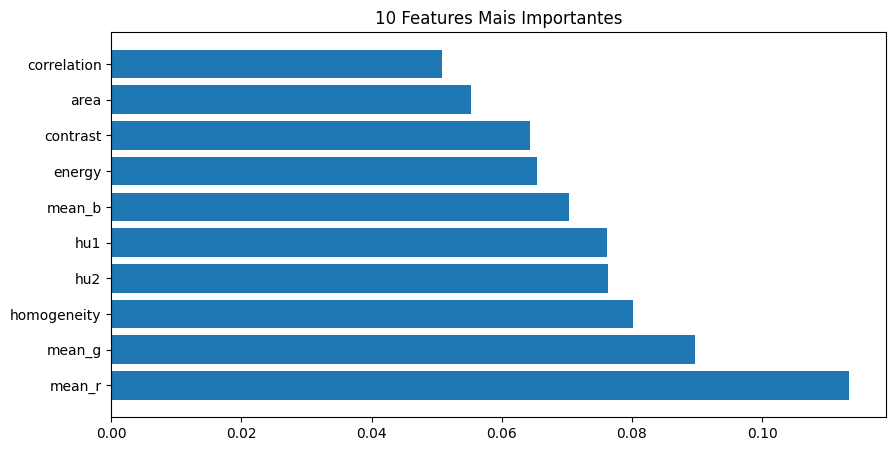

In [52]:
# Top features
# Este bloco gera um gráfico de barras com as 10 variáveis mais importantes identificadas pelo modelo Random Forest,
# facilitando a visualização dos atributos com maior impacto nas previsões

# Seleção das 10 variáveis mais importantes a partir da tabela de importâncias previamente ordenada
top10 = importancias.head(10)

# Criação da figura que receberá o gráfico
plt.figure(figsize=(10,5))

# Geração do gráfico de barras horizontais onde cada barra representa a importância de uma variável
plt.barh(
    top10["Feature"],
    top10["Importancia"]
)

# Definição do título do gráfico
plt.title("10 Features Mais Importantes")

# Salvamento da figura em arquivo de imagem para posterior utilização em relatórios e análises
plt.savefig("../outputs/top_features.png", bbox_inches="tight")

# Exibição do gráfico na tela
plt.show()

In [53]:
# Comparação final dos modelos

melhor_modelo = resultados.loc[resultados["Accuracy"].idxmax()]

print("Melhor modelo encontrado:")
print()

print("Modelo:", melhor_modelo["Modelo"])
print("Accuracy:", melhor_modelo["Accuracy"])
print("Precision:", melhor_modelo["Precision"])
print("Recall:", melhor_modelo["Recall"])
print("F1:", melhor_modelo["F1"])

Melhor modelo encontrado:

Modelo: Random Forest
Accuracy: 0.7921760391198044
Precision: 0.8049106466915338
Recall: 0.7921760391198044
F1: 0.7924285908898565
